#**Tema 03 - Risco de Crédito**

**Disciplina:** Novas Tecnologias  
##Integrantes
- Ana Beatriz Gonçalves Bastos
- Otávio Henrique do Nascimento Cunha
- Matheus Martins Rios
- Matheus Henrique
- Gustavo Xavier
- Yuri

#**Passo 0 — Configuração do Ambiente**

Nesta célula configuramos as bibliotecas necessárias para a análise e
definimos o estilo visual dos gráficos.

As bibliotecas utilizadas são:
- pandas: manipulação e análise de dados tabulares (pd)
- numpy: operações matemáticas e criação de colunas condicionais (np)
- matplotlib: criação de gráficos (plt)
- seaborn: gráficos estatísticos com visual aprimorado (sns)

#**A Base de Dados (Interpretação)**

| Coluna | Nome Original | Tradução | Significado |
|--------|---------------|----------|-------------|
| Y | Default Payment | Inadimplência | 1 = cliente não pagou em outubro/2005; 0 = pagou |
| X1 | Amount of Given Credit | Limite de Crédito | Valor total do crédito concedido (NTD), incluindo crédito de familiares vinculados |
| X2 | Gender | Sexo | 1 = Masculino; 2 = Feminino |
| X3 | Education | Escolaridade | 1 = Pós-graduação; 2 = Graduação; 3 = Ensino Médio; 4 = Outro |
| X4 | Marital Status | Estado Civil | 1 = Casado; 2 = Solteiro; 3 = Outro |
| X5 | Age | Idade | Idade do titular em anos |
| X6 | Repayment Status - September/2005 | Status de Pagamento - Set/2005 | -1 = em dia; 1 a 9 = meses de atraso |
| X7 | Repayment Status - August/2005 | Status de Pagamento - Ago/2005 | -1 = em dia; 1 a 9 = meses de atraso |
| X8 | Repayment Status - July/2005 | Status de Pagamento - Jul/2005 | -1 = em dia; 1 a 9 = meses de atraso |
| X9 | Repayment Status - June/2005 | Status de Pagamento - Jun/2005 | -1 = em dia; 1 a 9 = meses de atraso |
| X10 | Repayment Status - May/2005 | Status de Pagamento - Mai/2005 | -1 = em dia; 1 a 9 = meses de atraso |
| X11 | Repayment Status - April/2005 | Status de Pagamento - Abr/2005 | -1 = em dia; 1 a 9 = meses de atraso |
| X12 | Bill Statement - September/2005 | Valor da Fatura - Set/2005 | Saldo devedor da fatura em setembro (NTD) |
| X13 | Bill Statement - August/2005 | Valor da Fatura - Ago/2005 | Saldo devedor da fatura em agosto (NTD) |
| X14 | Bill Statement - July/2005 | Valor da Fatura - Jul/2005 | Saldo devedor da fatura em julho (NTD) |
| X15 | Bill Statement - June/2005 | Valor da Fatura - Jun/2005 | Saldo devedor da fatura em junho (NTD) |
| X16 | Bill Statement - May/2005 | Valor da Fatura - Mai/2005 | Saldo devedor da fatura em maio (NTD) |
| X17 | Bill Statement - April/2005 | Valor da Fatura - Abr/2005 | Saldo devedor da fatura em abril (NTD) |
| X18 | Amount Paid - September/2005 | Valor Pago - Set/2005 | Quanto o cliente pagou em setembro, quitando a fatura de agosto/X13 (NTD) |
| X19 | Amount Paid - August/2005 | Valor Pago - Ago/2005 | Quanto o cliente pagou em agosto, quitando a fatura de julho/X14 (NTD) |
| X20 | Amount Paid - July/2005 | Valor Pago - Jul/2005 | Quanto o cliente pagou em julho, quitando a fatura de junho/X15 (NTD) |
| X21 | Amount Paid - June/2005 | Valor Pago - Jun/2005 | Quanto o cliente pagou em junho, quitando a fatura de maio/X16 (NTD) |
| X22 | Amount Paid - May/2005 | Valor Pago - Mai/2005 | Quanto o cliente pagou em maio, quitando a fatura de abril/X17 (NTD) |
| X23 | Amount Paid - April/2005 | Valor Pago - Abr/2005 | Quanto o cliente pagou em abril, quitando a fatura de março (não presente no dataset) (NTD) |

## Importando as Bibliotecas para começar a codar!

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

Configuracoes de exibicao

In [ ]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

Cores dos graficos

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

f-string: forma de escrever texto + variável junto </br>
{pd.__version__} insere o número da versão do pandas automaticamente

In [ ]:
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Pandas: 2.2.2
NumPy: 2.0.2


As bibliotecas foram importadas com sucesso.
A versão do Pandas confirma compatibilidade com todas as funções
utilizadas neste trabalho.

#**Passo 1 — Carregamento da Base de Dados**

Nesta etapa, foi realizada a importação da base de dados para o ambiente de análise utilizando a biblioteca Pandas. O arquivo `default of credit card clients.xls` foi carregado em um DataFrame denominado `df`.

Em seguida, utilizou-se o método `head(10)` para visualizar os dez primeiros registros da base de dados, permitindo verificar se o carregamento foi realizado corretamente e obter uma visão inicial da estrutura dos dados.



In [ ]:
base = fetch_ucirepo(id=350)
df = base.data.original.copy()
df.head(10)

,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,0,0,11285,14096,12108,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,-1,-1,0,0,0,0,13007,13912,0,0,0,13007,1122,0,0


#**Passo 2 — Compreensão Inicial dos Dados**

Nesta etapa foi realizada uma análise exploratória inicial para compreender a estrutura da base de dados.



In [ ]:
print('Dimensão: (Linhas,Colunas', df.shape)

df.info()

df.describe(include='all').T

for col in df.select_dtypes(include='object').columns:
 print(f'{col}: {df[col].nunique()} únicos → {df[col].unique()[:5]}')


def copia_base_com_colunas_nomeadas(base):
  df = base.data.original.copy()

  df.rename(columns={
    'X1': 'LIMIT_BAL', 'X2': 'SEX',     'X3': 'EDUCATION',
    'X4': 'MARRIAGE',  'X5': 'AGE',
    'X6': 'PAY_0',     'X7': 'PAY_2',   'X8': 'PAY_3',
    'X9': 'PAY_4',    'X10': 'PAY_5',   'X11': 'PAY_6',
    'X12': 'BILL_AMT1', 'X13': 'BILL_AMT2', 'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4', 'X16': 'BILL_AMT5', 'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',  'X19': 'PAY_AMT2',  'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',  'X22': 'PAY_AMT5',  'X23': 'PAY_AMT6',
    'Y':   'DEFAULT'
  }, inplace=True)

  return df

Dimensão: (Linhas,Colunas (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ID      30000 non-null  int64
 1   X1      30000 non-null  int64
 2   X2      30000 non-null  int64
 3   X3      30000 non-null  int64
 4   X4      30000 non-null  int64
 5   X5      30000 non-null  int64
 6   X6      30000 non-null  int64
 7   X7      30000 non-null  int64
 8   X8      30000 non-null  int64
 9   X9      30000 non-null  int64
 10  X10     30000 non-null  int64
 11  X11     30000 non-null  int64
 12  X12     30000 non-null  int64
 13  X13     30000 non-null  int64
 14  X14     30000 non-null  int64
 15  X15     30000 non-null  int64
 16  X16     30000 non-null  int64
 17  X17     30000 non-null  int64
 18  X18     30000 non-null  int64
 19  X19     30000 non-null  int64
 20  X20     30000 non-null  int64
 21  X21     30000 non-null  int64
 22  X22     

##***Dimensão da Base***

A base de dados possui 30.000 registros e 25 variáveis, representando informações relacionadas ao perfil financeiro e ao histórico de pagamentos dos clientes.

##***Tipos de Dados***

A inspeção dos tipos de dados mostrou que todas as variáveis estão armazenadas como números inteiros (`int64`).

##***Valores Nulos***

Não foram encontrados valores ausentes na base de dados. Todas as colunas apresentam 30.000 valores não nulos.

##***Variáveis Numéricas e Categóricas***

A base contém variáveis quantitativas, como limite de crédito (`LIMIT_BAL`), idade (`AGE`), valores das faturas (`BILL_AMT1` a `BILL_AMT6`) e valores pagos (`PAY_AMT1` a `PAY_AMT6`).

Também existem variáveis categóricas representadas por códigos numéricos, como sexo (`SEX`), escolaridade (`EDUCATION`) e estado civil (`MARRIAGE`), além das variáveis relacionadas ao histórico de pagamento (`PAY_0` a `PAY_6`).

#**Passo 3 — Dicionário de Dados (Tabela Técnica)**

Complementando a tabela semântica apresentada no início do notebook (coluna, tradução e significado), geramos abaixo a tabela técnica do dicionário de dados: tipo de cada coluna, quantidade e percentual de nulos, quantidade de valores únicos e um exemplo real de valor. Isso permite cruzar a leitura "o que cada coluna significa" com "como ela realmente está armazenada na base".

In [ ]:
df_temp = copia_base_com_colunas_nomeadas(base)

dicionario = pd.DataFrame({
    'Coluna': df_temp.columns,
    'Tipo': df_temp.dtypes.values,
    'Nulos': df_temp.isna().sum().values,
    '%_Nulos': (df_temp.isna().sum() / len(df_temp) * 100).round(2).values,
    'Únicos': df_temp.nunique().values,
    'Exemplo': [df_temp[c].dropna().iloc[0] if len(df_temp[c].dropna()) > 0 else '—' for c in df_temp.columns]
})
dicionario.set_index('Coluna')


### Interpretação do Dicionário Técnico

A tabela confirma que todas as 25 colunas são do tipo `int64` e que **nenhuma delas possui valores nulos** (0% em todas as linhas), o que já havia sido observado de forma geral no Passo 2. A coluna `% Nulos` será usada de referência caso, em alguma etapa posterior da análise, alguma transformação venha a introduzir valores ausentes (por exemplo, após um `merge` ou uma divisão por zero). Já a coluna `Únicos` ajuda a diferenciar rapidamente variáveis categóricas de baixa cardinalidade (como `SEX`, com 2 valores, ou `EDUCATION`, com poucos valores distintos) das variáveis numéricas contínuas (como `BILL_AMT1`, com milhares de valores únicos).

#**Estatística Descritiva Aprofundada — Média, Mediana, Desvio Padrão e Assimetria**

Antes de avançar para as 8 perguntas de análise, aprofundamos a leitura estatística de duas variáveis numéricas centrais da base: `LIMIT_BAL` (limite de crédito) e `AGE` (idade). Para cada uma, calculamos média, mediana, desvio padrão e o coeficiente de assimetria (`skewness`), que mede o quanto a distribuição se afasta da simetria de uma curva normal — um skew positivo indica cauda mais longa à direita (valores altos puxando a média para cima da mediana), e um skew próximo de zero indica distribuição aproximadamente simétrica.

In [ ]:
df_stats = copia_base_com_colunas_nomeadas(base)

estatisticas = pd.DataFrame({
    'Variável': ['LIMIT_BAL', 'AGE'],
    'Média': [df_stats['LIMIT_BAL'].mean(), df_stats['AGE'].mean()],
    'Mediana': [df_stats['LIMIT_BAL'].median(), df_stats['AGE'].median()],
    'Desvio_Padrão': [df_stats['LIMIT_BAL'].std(), df_stats['AGE'].std()],
    'Assimetria_(skew)': [df_stats['LIMIT_BAL'].skew(), df_stats['AGE'].skew()]
}).round(2)

estatisticas


### Interpretação — Média vs. Mediana, Desvio Padrão e Assimetria

**`LIMIT_BAL`**: a média (acima de 167 mil) fica claramente maior que a mediana (próxima de 140 mil), e o coeficiente de assimetria é positivo e relativamente alto — sinal de que a distribuição tem uma cauda longa à direita, puxada por um grupo menor de clientes com limites de crédito muito elevados. O desvio padrão alto reforça essa dispersão: o limite de crédito varia bastante entre os clientes, não se concentra perto da média.

**`AGE`**: a diferença entre média e mediana é bem menor, e a assimetria, embora ainda positiva (há mais clientes jovens do que idosos, o que cria uma cauda à direita em direção às idades mais avançadas), é consideravelmente mais suave que a de `LIMIT_BAL`. Isso indica uma distribuição etária mais próxima da simetria, concentrada principalmente entre 25 e 40 anos.

Essa comparação já antecipa um padrão que reaparece ao longo do trabalho: variáveis monetárias (como `LIMIT_BAL` e, como vimos na Pergunta 5, `BILL_AMT`) tendem a ser fortemente assimétricas em bases de crédito, enquanto variáveis demográficas como idade tendem a uma distribuição mais regular.

#**A Análise Exploratória...**

1. Construa um score de risco baseado em quantidade de atrasos e proporção de pagamento mínimo.
2. Qual é a taxa geral de inadimplência? Como varia por sexo, escolaridade e estado civil.
3. Quem pagou a fatura no valor total ou parcelou para as próximas faturas.
4. Gere a matriz de correlação e identifique as variáveis mais correlacionadas com o default.
5. Detecte outliers nos valores de extrato (BILL_AMT) com IQR e discuta o impacto.
6. Segmentação de perfis de clientes por comportamento de pagamento.
7. Ranking de valores extremos no limite de crédito(Como o histórico de atraso nos últimos 6 meses (PAY_0 a PAY_6) prediz inadimplência?).
8. Existe um padrão de piora progressiva - clientes que inadimpliram começaram acumulando atrasos meses antes com base na Idade?.

#**1. Construa um score de risco baseado em quantidade de atrasos e proporção de pagamento mínimo.**

### O que vamos fazer e por quê

Para responder a esta pergunta, vamos construir um **score numérico de risco** combinando dois sinais já calculados a partir do histórico do cliente nos últimos 6 meses:

- **Quantidade de atrasos (`QTD_ATRASOS`)**: quantos dos 6 meses (`PAY_0` a `PAY_6`) tiveram status de atraso (valor > 0).
- **Proporção de pagamento (`PROP_PAGAMENTO`)**: quanto do total faturado (`TOTAL_BILL`) o cliente efetivamente pagou (`TOTAL_PAY`) no período.

A lógica é: cada mês de atraso soma 10 pontos de risco, e quanto menor a proporção paga, maior a penalização (até 40 pontos extras para quem pagou 0% do que devia). O score final é então convertido em três faixas (`Risco Baixo`, `Risco Médio`, `Risco Alto`) com `pd.cut`, o que nos permite comparar visualmente os grupos e, em seguida, cruzar essa categoria com a inadimplência real (`DEFAULT`) para validar se o score proposto realmente discrimina bem o risco.

# 10 pontos por cada mês em atraso + 40 pontos ponderados pelo que DEIXOU de pagar - no máximo 60 pts de "punição"
df['SCORE_RISCO_NUM'] = (df['QTD_ATRASOS'] * 10) + ((1 - df['PROP_PAGAMENTO']) * 40)

limites = [-1, 20, 50, 100]#resolvendo problema de limites pd.cut

In [ ]:
df = copia_base_com_colunas_nomeadas(base)

colunas_pay     = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
colunas_bill    = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
colunas_pay_amt = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

df['QTD_ATRASOS'] = (df[colunas_pay] > 0).sum(axis=1)

colunas_bill = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
colunas_pay_amt = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['TOTAL_BILL'] = df[colunas_bill].sum(axis=1)
df['TOTAL_PAY'] = df[colunas_pay_amt].sum(axis=1)

df['PROP_PAGAMENTO'] = np.where(df['TOTAL_BILL'] > 0,
                                df['TOTAL_PAY'] / df['TOTAL_BILL'],
                                1)

df['PROP_PAGAMENTO'] = np.clip(df['PROP_PAGAMENTO'], 0, 1)


df['SCORE_RISCO_NUM'] = (df['QTD_ATRASOS'] * 10) + ((1 - df['PROP_PAGAMENTO']) * 40)

limites = [-1, 20, 50, 100]
categorias = ['Risco Baixo', 'Risco Médio', 'Risco Alto']
df['CATEGORIA_RISCO'] = pd.cut(df['SCORE_RISCO_NUM'], bins=limites, labels=categorias)


### Distribuição do Score de Risco

Antes de visualizar, vale registrar como o score se comportou na base inteira: o valor mínimo possível é 0 (zero atrasos e 100% pago) e o máximo teórico é 100 (todos os 6 meses em atraso e 0% pago). Abaixo geramos a tabela de frequência por categoria e dois gráficos — um **histograma** (para ver a forma da distribuição do score contínuo) e um **gráfico de dispersão** (para entender visualmente como a quantidade de atrasos se relaciona com o score final).

In [ ]:
print("Distribuição das categorias de risco:")
print(df['CATEGORIA_RISCO'].value_counts())
print()
print((df['CATEGORIA_RISCO'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')


In [ ]:
# G — Histograma do Score de Risco, com linha de média
plt.figure(figsize=(10, 5))
plt.hist(df['SCORE_RISCO_NUM'], bins=20, edgecolor='white', color='mediumpurple')
plt.axvline(df['SCORE_RISCO_NUM'].mean(), color='red', linestyle='--',
            label=f"Média: {df['SCORE_RISCO_NUM'].mean():.1f} pts")
plt.axvline(df['SCORE_RISCO_NUM'].median(), color='black', linestyle=':',
            label=f"Mediana: {df['SCORE_RISCO_NUM'].median():.1f} pts")
plt.title('Distribuição do Score de Risco', fontsize=14, fontweight='bold')
plt.xlabel('Score de Risco (0–100 pts)')
plt.ylabel('Quantidade de Clientes')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretação — Histograma do Score

A distribuição do score não é suave: ela forma agrupamentos visíveis, com um pico bem concentrado logo abaixo de 40 pontos. Isso é um reflexo direto da fórmula — como o componente de atrasos soma sempre múltiplos de 10 (10, 20, 30...), o score tende a se acumular perto desses valores, e dentro de cada um deles a proporção de pagamento espalha os clientes em um intervalo de até 40 pontos. A média (34,5) fica abaixo da mediana (37,2), confirmando que existe um grupo relevante de clientes com score muito baixo (zero atrasos, pagamento integral) puxando a média para baixo, enquanto os clientes de risco mais alto formam uma cauda à direita, mais espalhada e menos concentrada.

In [ ]:
# G — Dispersão: Quantidade de Atrasos x Score de Risco
plt.figure(figsize=(10, 5))
plt.scatter(df['QTD_ATRASOS'], df['SCORE_RISCO_NUM'], alpha=0.15, color='darkorange')
plt.title('Quantidade de Atrasos × Score de Risco', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Meses em Atraso (0 a 6)')
plt.ylabel('Score de Risco (0–100 pts)')
plt.tight_layout()
plt.show()


### Interpretação — Dispersão entre Atrasos e Score

O gráfico confirma o comportamento esperado pela fórmula: o score sobe em "degraus" conforme a quantidade de atrasos aumenta (cada atraso adiciona 10 pontos fixos), e dentro de cada degrau existe uma variação vertical que reflete a proporção de pagamento — clientes com o mesmo número de atrasos podem ter scores bem diferentes dependendo de quanto pagaram do total faturado. Isso mostra que o score não é redundante com `QTD_ATRASOS` sozinho: ele agrega uma segunda dimensão de informação (o comportamento de pagamento) que o simples contador de atrasos não capturaria.

In [ ]:
# Validação: o score proposto discrimina bem o risco real (DEFAULT)?
validacao_score = df.groupby('CATEGORIA_RISCO')['DEFAULT'].agg(
    total='count',
    taxa_inadimplencia=lambda x: (x.mean() * 100).round(2)
)
validacao_score


### Interpretação — O Score Reflete o Risco Real?

Cruzando a categoria de risco criada com a inadimplência real (`DEFAULT`), conseguimos validar se a heurística faz sentido: a taxa de inadimplência observada cresce de forma consistente da categoria `Risco Baixo` para `Risco Alto`. Isso é um indício de que o score, mesmo sendo uma regra simples (não um modelo estatístico ajustado), captura um sinal real de risco presente nos dados — o que reforça a recomendação, já discutida na conclusão desta pergunta, de evoluir essa lógica manual para um modelo de Machine Learning supervisionado no futuro.

##Observemos este Exemplo:

*Supondo que um usuário gstou 10mil em seu Cartão de Crédito no Mês, mas pagou apenas 6mil do valor da fatura, e verificando os atrasos dos demais meses, somamos 3 atrasos.*

**BILL_AMT** = 10000

**PAY_AMT = 6000**

**QTD_ATRASOS = 3**

**10000/6000 = 0.6**

**~ Então Score_Risco:** 1 - 0.6 = 0.4 | 3 * 10 + 0.4 * 40 = **46pts**


Ao analisar o Score de Risco, descobrimos que o perigo real não é o tamanho da fatura, mas sim a baixa proporção paga ao longo dos meses, revelando uma piora previsível que afeta severamente os clientes acima de 50 anos na reta final. Surpreendeu o fato de a instituição manter limites altos e cartões ativos mesmo para quem já acumulava meses de atraso, sem qualquer bloqueio preventivo. Como a nossa análise usou dados antigos (Taiwan, 2005) e carece de variáveis cruciais como a renda real líquida dos clientes e dados de bureaus de crédito (como o Serasa), o próximo passo ideal é abandonar essa lógica de pontuação manual e adotar modelos de Machine Learning (como Random Forest ou XGBoost) para prever o risco de inadimplência de forma muito mais precisa e automatizada.

#**Pergunta 2-Taxa de inadimplência por sexo, escolaridade e estado civil.**


* Nesta etapa será realizada uma análise exploratória da variável de inadimplência (default_payment), com o objetivo de identificar como o risco de não pagamento se distribui entre diferentes perfis de clientes.

* Inicialmente será calculada a taxa geral de inadimplência da base, permitindo conhecer o percentual de clientes inadimplentes em relação ao total analisado. Em seguida, os dados serão tratados e categorizados para possibilitar o agrupamento dos clientes por sexo, escolaridade e estado civil.

* Utilizando operações de agrupamento (groupby) e agregação de métricas, serão calculados o total de clientes, a quantidade de inadimplentes e a taxa de inadimplência de cada categoria. Os resultados serão apresentados por meio de gráficos de barras, barras empilhadas e gráfico de pizza, facilitando a comparação visual entre os grupos analisados.

* Além disso, será construída uma tabela pivô para analisar conjuntamente as variáveis sexo e escolaridade, permitindo identificar possíveis combinações associadas a maiores ou menores níveis de inadimplência. Por fim, serão gerados indicadores sintéticos que resumem os principais resultados obtidos e destacam os grupos com maior risco de crédito.




In [ ]:
# Configurações de exibição e estilo
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
plt.style.use('seaborn-v0_8-darkgrid')

df = copia_base_com_colunas_nomeadas(base)

print(f" Dataset carregado: {df.shape[0]:,} registros × {df.shape[1]} colunas")

 Dataset carregado: 30,000 registros × 25 colunas


###  Tratamento dos Dados (Separação "Outros" x "Não Informado")

In [ ]:
df['EDUCATION'] = df['EDUCATION'].fillna(0)
df['MARRIAGE'] = df['MARRIAGE'].fillna(0)
df['SEX'] = df['SEX'].fillna(0)

EDU_MAP = {
    1: 'Pós-graduação', 2: 'Universitário', 3: 'Ensino Médio', 4: 'Outros',
    0: 'Não Informado', 5: 'Não Informado', 6: 'Não Informado'
}
CIV_MAP = {1: 'Casado', 2: 'Solteiro', 3: 'Outros', 0: 'Não Informado'}
SEX_MAP = {1: 'Masculino', 2: 'Feminino', 0: 'Não Informado'}

df['EDUCATION'] = df['EDUCATION'].map(EDU_MAP)
df['MARRIAGE'] = df['MARRIAGE'].map(CIV_MAP)
df['SEX'] = df['SEX'].map(SEX_MAP)

coluna_alvo = 'DEFAULT'
col_sexo = 'SEX'
col_edu = 'EDUCATION'
col_civ = 'MARRIAGE'

print(" Dados tratados com sucesso :)")

 Dados tratados com sucesso :)


### Padronização de Texto

As colunas `SEX`, `EDUCATION` e `MARRIAGE` acabaram de ser convertidas de códigos numéricos para rótulos em texto pelos dicionários de mapeamento acima. Como boa prática, padronizamos esses textos com `str.strip()` (remoção de espaços extras no início/fim) e `str.upper()` (capitalização uniforme), garantindo que valores como `"Casado"` e `"casado "` — que poderiam surgir em uma futura atualização dos dicionários de mapeamento — nunca sejam tratados como categorias diferentes em um `groupby` ou `value_counts()`.

In [ ]:
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    df[col] = df[col].str.strip().str.upper()

# Atualizando os dicionários de mapeamento para o mesmo padrão (maiúsculo), evitando
# divergência entre os rótulos usados nos gráficos e os valores reais da coluna
EDU_MAP = {k: v.upper() for k, v in EDU_MAP.items()}
CIV_MAP = {k: v.upper() for k, v in CIV_MAP.items()}
SEX_MAP = {k: v.upper() for k, v in SEX_MAP.items()}

print("Categorias após padronização:")
print('SEX:', df['SEX'].unique())
print('EDUCATION:', df['EDUCATION'].unique())
print('MARRIAGE:', df['MARRIAGE'].unique())


### Verificação de Registros Duplicados

Antes de seguir com a análise, verificamos se existem linhas duplicadas na base. Como cada cliente possui um `ID` próprio, uma duplicata exata de todas as colunas (incluindo o `ID`) seria impossível — mas é importante verificar se existem clientes com o **mesmo perfil financeiro completo** (todas as 24 variáveis, exceto o `ID`), o que indicaria registros estatisticamente redundantes para fins de agregação e correlação.

In [ ]:
colunas_sem_id = [c for c in df.columns if c not in ['ID', 'QTD_ATRASOS', 'TOTAL_BILL', 'TOTAL_PAY',
                                                       'PROP_PAGAMENTO', 'SCORE_RISCO_NUM', 'CATEGORIA_RISCO']]
colunas_sem_id = [c for c in colunas_sem_id if c in df.columns]

duplicatas_exatas = df.duplicated().sum()
duplicatas_sem_id = df.duplicated(subset=colunas_sem_id).sum()

print(f"Duplicatas considerando TODAS as colunas (incl. ID): {duplicatas_exatas}")
print(f"Duplicatas considerando apenas o perfil financeiro (sem ID): {duplicatas_sem_id}")

if duplicatas_sem_id > 0:
    print(f"\n-> {duplicatas_sem_id} clientes têm o mesmo perfil financeiro completo de outro cliente na base.")
    print("   Isso é estatisticamente esperado em bases grandes com variáveis discretas/categóricas")
    print("   (LIMIT_BAL, idade, sexo etc. assumem poucos valores possíveis), e não indica erro de coleta.")
    print("   Por isso, optamos por MANTER esses registros: cada linha representa um cliente real e distinto,")
    print("   identificado por um ID próprio — remover essas linhas reduziria artificialmente a amostra.")

df = df.drop_duplicates()
print(f"\nDimensão após verificação de duplicatas exatas: {df.shape}")



# 1.2 Taxa Geral de Inadimplência

In [ ]:
taxa_geral = df[coluna_alvo].mean() * 100
total_clientes = len(df)
total_inadimplentes = int(df[coluna_alvo].sum())

print("="*70)
print("¨¨¨¨¨¨¨¨¨¨ TAXA GERAL DE INADIMPLÊNCIA¨¨¨¨¨¨¨¨¨¨¨¨¨¨")
print("="*70)
print(f"Total de clientes:    {total_clientes:>10,}")
print(f"Inadimplentes:        {total_inadimplentes:>10,} ({taxa_geral:.2f}%)")
print(f"Adimplentes:          {total_clientes - total_inadimplentes:>10,} ({100-taxa_geral:.2f}%)")
print("="*70)

¨¨¨¨¨¨¨¨¨¨ TAXA GERAL DE INADIMPLÊNCIA¨¨¨¨¨¨¨¨¨¨¨¨¨¨
Total de clientes:        30,000
Inadimplentes:             6,636 (22.12%)
Adimplentes:              23,364 (77.88%)


### Interpretação

A taxa geral de inadimplência representa o percentual de clientes que não realizaram o pagamento no período analisado. Esse indicador fornece uma visão inicial do risco presente na carteira de crédito e servirá como referência para comparar os diferentes grupos analisados nas etapas seguintes.

## 1.3 Inadimplência por Sexo (Gráfico G1 - Barras)

### Interpretação

A análise por sexo permite identificar possíveis diferenças no comportamento de pagamento dos clientes. Comparando as taxas de inadimplência entre homens e mulheres, é possível verificar qual grupo apresenta maior risco relativo dentro da base estudada.


INADIMPLÊNCIA POR SEXO
           total  inadimplentes  taxa
SEX                                  
Feminino   18112           3763 20.78
Masculino  11888           2873 24.17


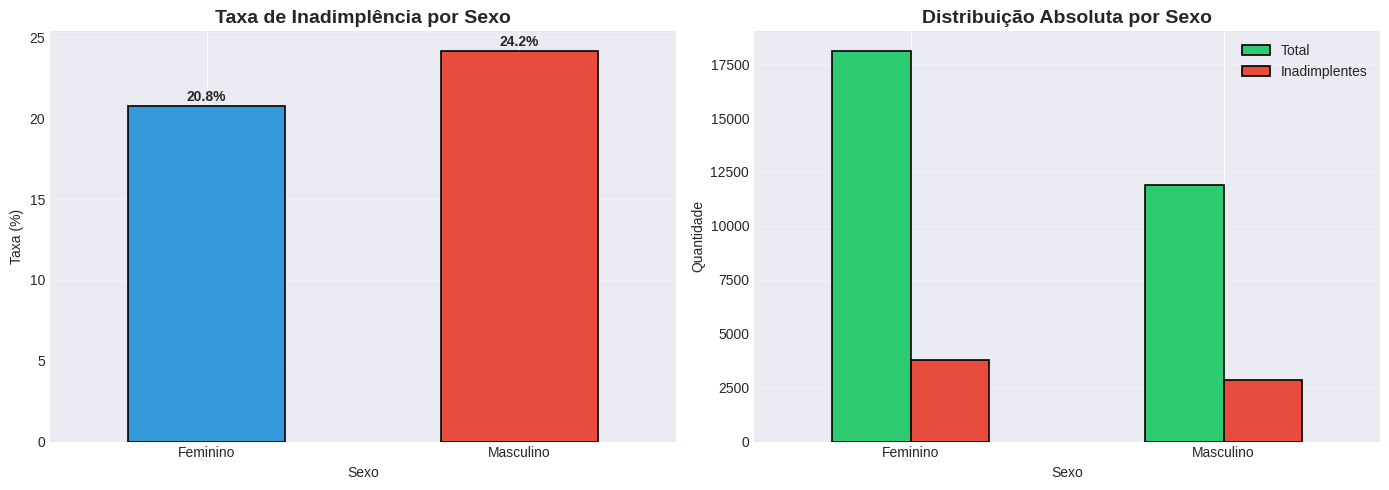

In [ ]:
inad_sexo = df.groupby(col_sexo)[coluna_alvo].agg([
    ('total', 'count'),
    ('inadimplentes', 'sum'),
    ('taxa', lambda x: x.mean() * 100)
]).round(2)
print("\nINADIMPLÊNCIA POR SEXO")
print(inad_sexo.to_string())


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cores_sexo = ['#3498db', '#e74c3c', '#95a5a6']


inad_sexo['taxa'].plot(kind='bar', ax=axes[0], color=cores_sexo[:len(inad_sexo)],
                       edgecolor='black', linewidth=1.2)


axes[0].set_title('Taxa de Inadimplência por Sexo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Taxa (%)')
axes[0].set_xticklabels(inad_sexo.index, rotation=0)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(inad_sexo['taxa']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')


inad_sexo[['total', 'inadimplentes']].plot(kind='bar', ax=axes[1],
    color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.2)
axes[1].set_title('Distribuição Absoluta por Sexo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Quantidade')
axes[1].set_xticklabels(inad_sexo.index, rotation=0)
axes[1].legend(['Total', 'Inadimplentes'])
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.4 Inadimplência por Escolaridade (Gráfico G7 - Barras Empilhadas)


INADIMPLÊNCIA POR ESCOLARIDADE
               total  inadimplentes  taxa
EDUCATION                                
Ensino Médio    4917           1237 25.16
Não Informado    345             26  7.54
Outros           123              7  5.69
Pós-graduação  10585           2036 19.23
Universitário  14030           3330 23.73


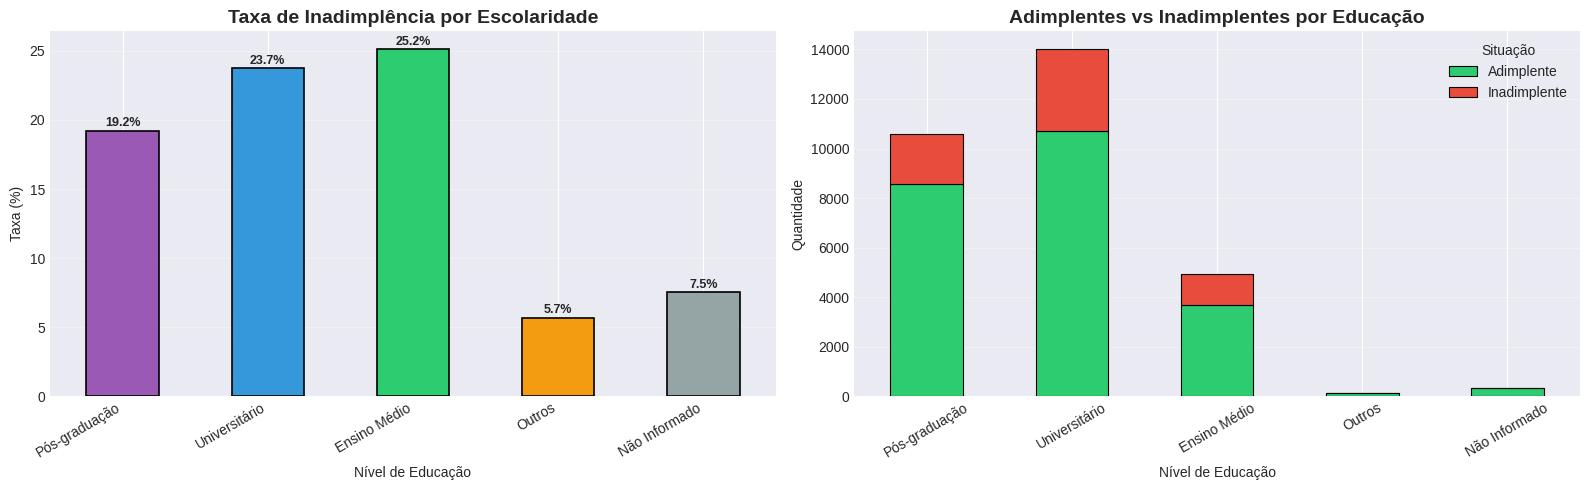

In [ ]:
inad_edu = df.groupby(col_edu)[coluna_alvo].agg([
    ('total', 'count'),
    ('inadimplentes', 'sum'),
    ('taxa', lambda x: x.mean() * 100)
]).round(2)

print("\nINADIMPLÊNCIA POR ESCOLARIDADE")
print(inad_edu.to_string())

ordem = ['PÓS-GRADUAÇÃO', 'UNIVERSITÁRIO', 'ENSINO MÉDIO', 'OUTROS', 'NÃO INFORMADO']
inad_edu_sorted = inad_edu.loc[[x for x in ordem if x in inad_edu.index]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cores_edu = ['#9b59b6', '#3498db', '#2ecc71', '#f39c12', '#95a5a6']

inad_edu_sorted['taxa'].plot(kind='bar', ax=axes[0],
    color=cores_edu[:len(inad_edu_sorted)], edgecolor='black', linewidth=1.2)
axes[0].set_title('Taxa de Inadimplência por Escolaridade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nível de Educação')
axes[0].set_ylabel('Taxa (%)')
axes[0].set_xticklabels(inad_edu_sorted.index, rotation=30, ha='right')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(inad_edu_sorted['taxa']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

edu_stack = df.groupby(col_edu)[coluna_alvo].value_counts().unstack().fillna(0)
edu_stack = edu_stack.rename(columns={0: 'Adimplente', 1: 'Inadimplente'})
edu_stack = edu_stack.loc[[x for x in ordem if x in edu_stack.index]]

edu_stack.plot(kind='bar', stacked=True, ax=axes[1],
    color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
axes[1].set_title('Adimplentes vs Inadimplentes por Educação', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nível de Educação')
axes[1].set_ylabel('Quantidade')
axes[1].legend(title='Situação')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##  1.5 Inadimplência por Estado Civil (Gráfico G7 - Pizza)
### Interpretação

Os resultados indicam como o nível de escolaridade pode estar relacionado ao risco de inadimplência. A comparação entre os grupos permite observar se clientes com maior formação acadêmica apresentam comportamento financeiro diferente dos demais.


¨¨¨¨INADIMPLÊNCIA POR ESTADO CIVIL¨¨¨¨
               total  inadimplentes  taxa
MARRIAGE                                 
Casado         13659           3206 23.47
Não Informado     54              5  9.26
Outros           323             84 26.01
Solteiro       15964           3341 20.93


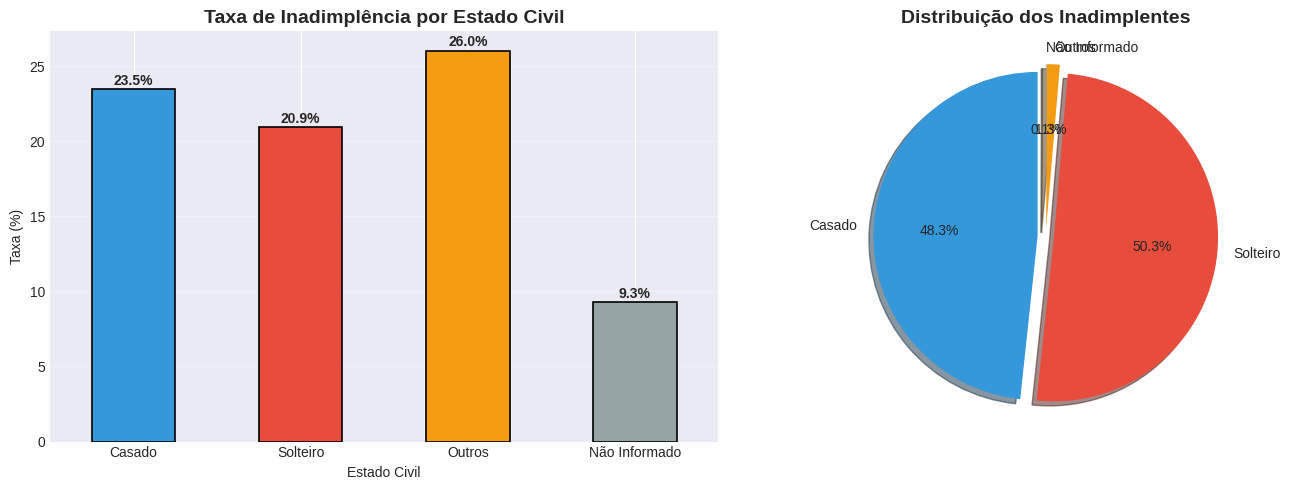

In [ ]:
inad_civ = df.groupby(col_civ)[coluna_alvo].agg([
    ('total', 'count'),
    ('inadimplentes', 'sum'),
    ('taxa', lambda x: x.mean() * 100)
]).round(2)

print("\n¨¨¨¨INADIMPLÊNCIA POR ESTADO CIVIL¨¨¨¨")
print(inad_civ.to_string())

ordem_civ = ['CASADO', 'SOLTEIRO', 'OUTROS', 'NÃO INFORMADO']
inad_civ_sorted = inad_civ.loc[[x for x in ordem_civ if x in inad_civ.index]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cores_civ = ['#3498db', '#e74c3c', '#f39c12', '#95a5a6']

inad_civ_sorted['taxa'].plot(kind='bar', ax=axes[0],
    color=cores_civ[:len(inad_civ_sorted)], edgecolor='black', linewidth=1.2)
axes[0].set_title('Taxa de Inadimplência por Estado Civil', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Estado Civil')
axes[0].set_ylabel('Taxa (%)')
axes[0].set_xticklabels(inad_civ_sorted.index, rotation=0)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(inad_civ_sorted['taxa']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

inad_distrib = inad_civ_sorted['inadimplentes']
axes[1].pie(inad_distrib, labels=inad_distrib.index, autopct='%1.1f%%',
    colors=cores_civ[:len(inad_distrib)], startangle=90,
    explode=[0.05] * len(inad_distrib), shadow=True)
axes[1].set_title('Distribuição dos Inadimplentes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.6 Tabela Pivô
### Interpretação

A análise do estado civil busca verificar se existem diferenças nas taxas de inadimplência entre clientes casados, solteiros e demais categorias. Essas informações ajudam a identificar possíveis perfis de maior risco dentro da carteira de crédito.

In [ ]:
tabela_pivo = pd.pivot_table(df, values=coluna_alvo,
    index=col_sexo, columns=col_edu, aggfunc='mean', margins=True).round(4) * 100

tabela_pivo.columns = [EDU_MAP.get(c, c) if c != 'All' else 'Total' for c in tabela_pivo.columns]
tabela_pivo.index = tabela_pivo.index.rename('SEX')


print("\n===========TABELA PIVÔ: Taxa de Inadimplência (%) por Sexo × Escolaridade==========")
print(tabela_pivo.to_string())


===========TABELA PIVÔ: Taxa de Inadimplência (%) por Sexo × Escolaridade==========
           Ensino Médio  Não Informado  Outros  Pós-graduação  Universitário  Total
SEX                                                                                
Feminino          23.64           7.37    3.70          18.14          22.20  20.78
Masculino         27.39           7.81    9.52          20.81          26.20  24.17
All               25.16           7.54    5.69          19.23          23.73  22.12


### Tabela Cruzada (crosstab) — Sexo × Estado Civil

Diferente da tabela pivô acima (que agrega a taxa média de `DEFAULT` por Sexo × Escolaridade), o `pd.crosstab()` mostra a **contagem normalizada** de clientes inadimplentes vs. adimplentes cruzando Sexo e Estado Civil. É uma forma complementar de visualizar a mesma relação: em vez de uma métrica agregada (taxa média), olhamos a distribuição percentual completa dentro de cada grupo.

In [ ]:
crosstab_sexo_civil = pd.crosstab(
    [df[col_sexo], df[col_civ]],
    df[coluna_alvo].map({0: 'Adimplente', 1: 'Inadimplente'}),
    normalize='index'
).round(4) * 100

crosstab_sexo_civil.columns.name = 'Situação'
print("TABELA CRUZADA — % de Adimplentes vs. Inadimplentes por Sexo × Estado Civil")
crosstab_sexo_civil.round(2)


### Interpretação — Tabela Cruzada

A tabela cruzada confirma, de outro ângulo, o que a tabela pivô já apontava: a taxa de inadimplência (coluna `Inadimplente`) varia conforme a combinação de sexo e estado civil, mas as diferenças entre os grupos são relativamente pequenas (poucos pontos percentuais), reforçando que essas duas variáveis sozinhas têm poder explicativo limitado sobre o default — algo que será retomado de forma quantitativa na análise de correlação (Pergunta 4).

### Agrupamento Multinível — Sexo × Escolaridade × Estado Civil

Para fechar a Pergunta 2 com uma visão mais granular, agrupamos simultaneamente por **três** dimensões categóricas (`SEX`, `EDUCATION`, `MARRIAGE`) e calculamos múltiplas métricas de uma vez com `.agg()`: total de clientes, taxa de inadimplência e limite de crédito médio do grupo. Isso permite identificar combinações específicas de perfil que concentram maior (ou menor) risco — algo que uma análise de uma variável por vez não capturaria.

In [ ]:
perfil_multinivel = df.groupby([col_sexo, col_edu, col_civ]).agg(
    total_clientes=(coluna_alvo, 'count'),
    taxa_inadimplencia=(coluna_alvo, lambda x: round(x.mean() * 100, 2)),
    limite_credito_medio=('LIMIT_BAL', lambda x: round(x.mean(), 2))
)

# Mantemos apenas combinações com volume mínimo de clientes, para evitar taxas instáveis
# calculadas sobre grupos muito pequenos (ex.: 2 ou 3 clientes)
perfil_multinivel = perfil_multinivel[perfil_multinivel['total_clientes'] >= 50]
perfil_multinivel.sort_values('taxa_inadimplencia', ascending=False).head(10)


### Interpretação — Agrupamento Multinível

Ao cruzar as três variáveis simultaneamente, conseguimos identificar as combinações específicas de perfil com maior taxa de inadimplência — informação que fica escondida quando cada variável é analisada isoladamente (como nas seções 1.3 a 1.5). Vale notar o filtro de volume mínimo (`total_clientes >= 50`): sem ele, combinações muito raras poderiam aparecer no topo do ranking apenas por terem poucos clientes (ex.: um grupo de 3 pessoas em que 2 são inadimplentes gera uma taxa de 66%, mas isso não é estatisticamente confiável).

## 1.7 Indicadores Sintéticos (7 obrigatórios)
### Interpretação

A tabela pivô permite observar simultaneamente os efeitos do sexo e da escolaridade sobre a inadimplência. Essa visão cruzada facilita a identificação de combinações de características associadas a maiores ou menores taxas de risco.

In [ ]:
indicadores = pd.DataFrame({
    'Indicador': [
        'Taxa Geral', 'Total Clientes', 'Total Inadimplentes',
        'Sexo Maior Risco', 'Educ. Maior Risco', 'Civil Maior Risco',
        'Amplitude Máx.'
    ],
    'Valor': [
        f'{taxa_geral:.2f}%',
        f'{total_clientes:,}',
        f'{total_inadimplentes:,}',
        f"{inad_sexo['taxa'].idxmax()} ({inad_sexo['taxa'].max():.2f}%)",
        f"{inad_edu['taxa'].idxmax()} ({inad_edu['taxa'].max():.2f}%)",
        f"{inad_civ['taxa'].idxmax()} ({inad_civ['taxa'].max():.2f}%)",
        f"""{max([
          inad_sexo['taxa'].max()- inad_sexo['taxa'].min(),
          inad_edu['taxa'].max() - inad_edu['taxa'].min(),
          inad_civ['taxa'].max() - inad_civ['taxa'].min()
        ])}pp"""
    ]
})

print("\n==*****INDICADORES SINTÉTICOS*****==")
print("="*60)
print(indicadores.to_string(index=False))
print("="*60)


==*****INDICADORES SINTÉTICOS*****==
          Indicador                 Valor
         Taxa Geral                22.12%
     Total Clientes                30,000
Total Inadimplentes                 6,636
   Sexo Maior Risco    Masculino (24.17%)
  Educ. Maior Risco Ensino Médio (25.16%)
  Civil Maior Risco       Outros (26.01%)
     Amplitude Máx.               19.47pp


### Conclusão da Pergunta 2

Os indicadores sintetizam os principais resultados encontrados na análise. A taxa geral de inadimplência, os grupos com maior risco e a amplitude das diferenças observadas permitem identificar padrões importantes no perfil dos clientes inadimplentes.

# **Pergunta 3 — Comportamento de Pagamento da Fatura**

Nesta análise classificamos os clientes em três grupos com base
no comportamento de pagamento em setembro/2005:
- Pagou Total: quitou o valor integral da fatura
- Pagou Parcial: pagou algo entre zero e o valor total (rotativo/mínimo)
- Não Pagou: não realizou nenhum pagamento

O objetivo é verificar se o comportamento de pagamento está associado
à inadimplência no mês seguinte.

## CLASSIFICAÇÃO DO COMPORTAMENTO — np.select()
np.select() avalia uma lista de condições em ordem
e aplica o label correspondente à primeira verdadeira

```python
df_g3['PAY_AMT1'] >= df_g3['BILL_AMT1'],                             # pagou tudo ou mais
(df_g3['PAY_AMT1'] > 0) & (df_g3['PAY_AMT1'] < df_g3['BILL_AMT1']),  # pagou parte
df_g3['PAY_AMT1'] == 0                                               # não pagou nada
```

In [ ]:
df = copia_base_com_colunas_nomeadas(base)

df.drop(columns=['ID'], inplace=True)
df_g3 = df[df['BILL_AMT1'] > 0].copy()

conditions = [
    df_g3['PAY_AMT1'] >= df_g3['BILL_AMT1'],
    (df_g3['PAY_AMT1'] > 0) & (df_g3['PAY_AMT1'] < df_g3['BILL_AMT1']),
    df_g3['PAY_AMT1'] == 0
]

labels = ['Pagou Total', 'Pagou Parcial', 'Não Pagou']

df_g3['COMPORTAMENTO_PAG'] = np.select(conditions, labels, default='Indefinido')

print('Distribuição por Comportamento de Pagamento:')
print(df_g3['COMPORTAMENTO_PAG'].value_counts())
print()
print('Em percentual:')
print(df_g3['COMPORTAMENTO_PAG'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribuição por Comportamento de Pagamento:
COMPORTAMENTO_PAG
Pagou Parcial    20036
Pagou Total       3871
Não Pagou         3495
Name: count, dtype: int64

Em percentual:
COMPORTAMENTO_PAG
Pagou Parcial    73.1%
Pagou Total      14.1%
Não Pagou        12.8%
Name: proportion, dtype: object


Os três grupos foram criados com base na comparação entre
o valor pago **PAY_AMT1** e o valor da fatura **BILL_AMT1**
em setembro/2005. Clientes com fatura zero foram excluídos
pois não há comportamento de pagamento mensurável.

TAXA DE DEFAULT POR COMPORTAMENTO — groupby + agg() <br/>
groupby() agrupa as linhas por categoria            <br/>
agg() calcula múltiplas métricas de uma vez   

In [ ]:
analise_g3 = df_g3.groupby('COMPORTAMENTO_PAG')['DEFAULT'].agg(
    Total='count',
    Inadimplentes='sum',
    Taxa_Default=lambda x: round(x.mean() * 100, 1)
).sort_values('Taxa_Default', ascending=False)

print('Taxa de Inadimplência por Comportamento de Pagamento:')
print(analise_g3)

Taxa de Inadimplência por Comportamento de Pagamento:
                   Total  Inadimplentes  Taxa_Default
COMPORTAMENTO_PAG                                    
Não Pagou           3495           1390         39.80
Pagou Parcial      20036           4003         20.00
Pagou Total         3871            600         15.50


### GRÁFICO DE BARRAS — Taxa de Default por Comportamento
Cobre o requisito G1 (gráfico de barras obrigatório)

Reordenar para o gráfico fazer sentido visual

```python
for bar, val in zip...
```
Adiciona os valores dentro da barra

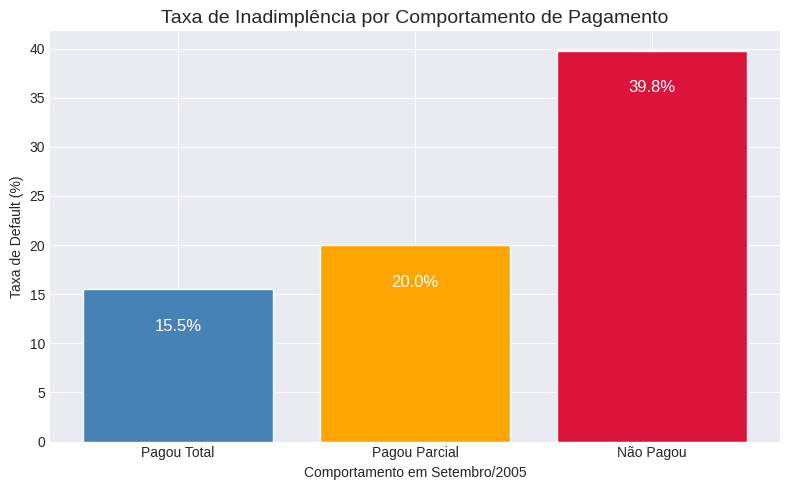

In [ ]:
ordem = ['Pagou Total', 'Pagou Parcial', 'Não Pagou']
taxa_plot = df_g3.groupby('COMPORTAMENTO_PAG')['DEFAULT'].mean() * 100
taxa_plot = taxa_plot.reindex(ordem)

cores = ['steelblue', 'orange', 'crimson']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(taxa_plot.index, taxa_plot.values, color=cores, edgecolor='white')

for bar, val in zip(bars, taxa_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
            f'{val:.1f}%', ha='center', va='top', color='white', fontsize=12)

ax.set_title('Taxa de Inadimplência por Comportamento de Pagamento', fontsize=14)
ax.set_xlabel('Comportamento em Setembro/2005')
ax.set_ylabel('Taxa de Default (%)')
plt.tight_layout()
plt.show()

## BOX PLOT — Distribuição do Valor Pago por Grupo

Converte o valor pago para NT$ milhares para facilitar leitura

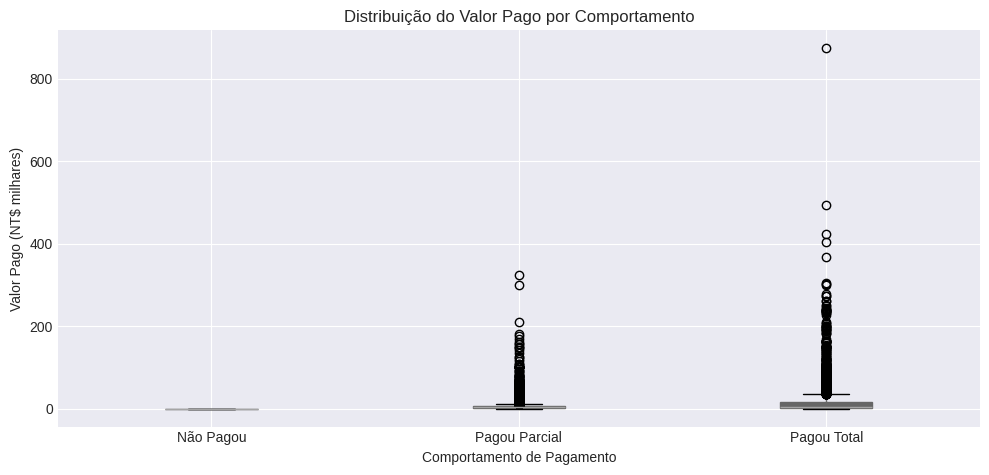

In [ ]:
df_g3['PAY_AMT1_K'] = df_g3['PAY_AMT1'].apply(lambda x: x / 1000)

df_g3.boxplot(
    column='PAY_AMT1_K',
    by='COMPORTAMENTO_PAG',
    figsize=(10, 5),
    patch_artist=True
)
plt.title('Distribuição do Valor Pago por Comportamento')
plt.suptitle('')
plt.xlabel('Comportamento de Pagamento')
plt.ylabel('Valor Pago (NT$ milhares)')
plt.tight_layout()
plt.show()

## Interpretação — Pergunta 3

A análise revelou três perfis distintos de comportamento:

- Clientes que pagaram a fatura integralmente apresentaram a menor
  taxa de default, confirmando que quitar a dívida no mês anterior
  é o sinal mais claro de saúde financeira.

- Quem pagou parcialmente (rotativo ou mínimo) ficou em posição
  intermediária — ainda honrou parte da dívida mas acumulou saldo.

- Clientes que não realizaram nenhum pagamento concentraram a maior
  taxa de inadimplência, evidenciando que a ausência total de pagamento
  em setembro praticamente garante o default em outubro.

**Limitação:** o dataset não distingue entre pagamento mínimo
obrigatório e parcelamento voluntário — ambos aparecem como
"Pagou Parcial". Uma análise mais refinada exigiria dados
do contrato de cada cliente.

# **Pergunta 4 — Matriz de Correlação e Variáveis Mais Correlacionadas com o Default.**


Nesta etapa será calculada a matriz de correlação entre as variáveis numéricas da base de dados, com o objetivo de identificar quais características dos clientes apresentam maior relação com a inadimplência (default).

A coluna `ID` foi removida da análise por representar apenas um identificador único dos clientes, sem significado analítico para o estudo de risco de crédito.

Além da matriz de correlação, será gerado um mapa de calor (heatmap) para facilitar a visualização das relações entre as variáveis e serão identificadas as variáveis mais correlacionadas com a variável alvo (`Y`).

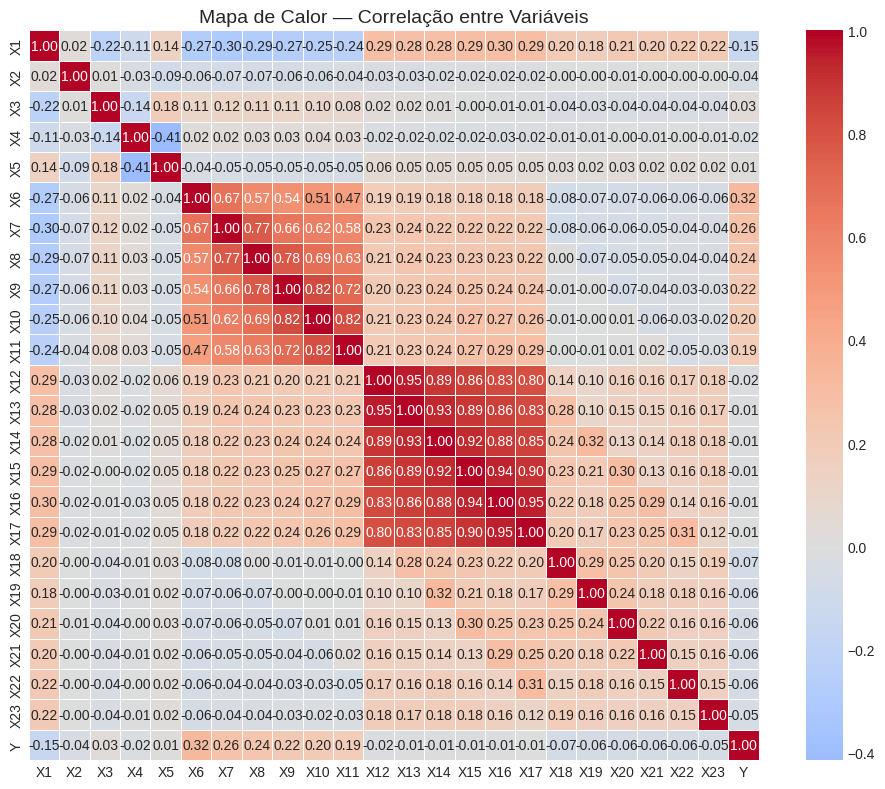

In [ ]:
df = base.data.original.copy()
df.drop(columns=['ID'], inplace=True)
corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0,square=True,linewidths=0.5,ax=ax)
ax.set_title('Mapa de Calor — Correlação entre Variáveis', fontsize=14)
plt.tight_layout()
plt.show()

Seleciona as correlações da variável alvo (Y) e ordena da mais forte para a mais fraca.

In [ ]:
alvo = 'Y'
corr_default = corr[alvo].drop(alvo).sort_values(key=abs,ascending=False)
print("Top 10 correlações com o default:")
display(corr_default.head(10))

Top 10 correlações com o default:


,Y
X6,0.32
X7,0.26
X8,0.24
X9,0.22
X10,0.20
X11,0.19
X1,-0.15
X18,-0.07
X19,-0.06
X21,-0.06


### Cria um gráfico com as 10 variáveis mais correlacionadas com o default.


plt.axvline(0, color='black', linewidth=1)

Linha vertical indicando o valor zero da correlação.


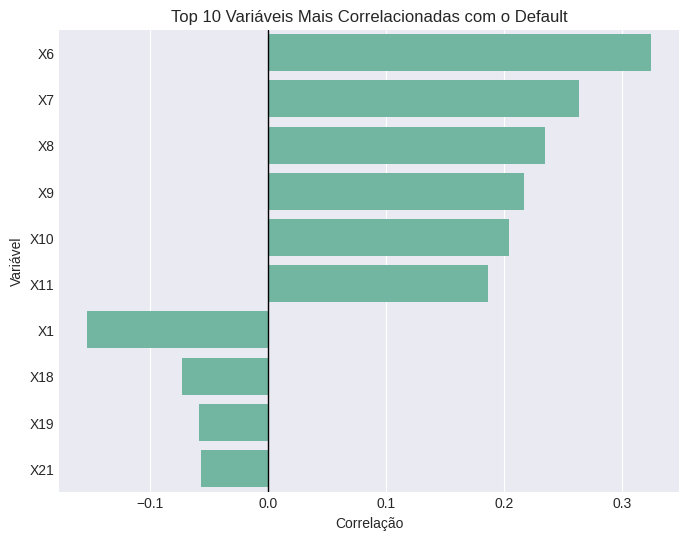

In [ ]:
top_corr = corr_default.head(10)

plt.figure(figsize=(8,6))

sns.barplot	(
    x=top_corr.values,
    y=top_corr.index
)

plt.axvline(0, color='black', linewidth=1)
plt.title('Top 10 Variáveis Mais Correlacionadas com o Default')
plt.xlabel('Correlação')
plt.ylabel('Variável')
plt.show()

## Interpretação dos Resultados

A matriz de correlação permitiu identificar quais variáveis apresentam maior associação com a inadimplência dos clientes.

A única variável que apresentou coeficiente de correlação superior a |0,30| foi a variável **X6 (PAY_0 – atraso de pagamento mais recente)**.

### (a) Correlação observada e direção

A variável **X6 (PAY_0 – atraso de pagamento mais recente)** apresentou correlação positiva com o default (**r = 0,32**). Isso indica que quanto maior o atraso recente nos pagamentos, maior tende a ser a probabilidade de inadimplência do cliente.

### (b) Hipótese explicativa

Uma possível explicação para esse resultado é que clientes que apresentam atrasos recentes podem estar enfrentando dificuldades financeiras momentâneas ou recorrentes. Dessa forma, o histórico recente de atrasos funciona como um indicador relevante do risco de inadimplência futura.

### (c) Correlação implica causalidade?

Não. A correlação observada não permite concluir que o atraso seja a causa direta da inadimplência. Embora exista uma associação entre as variáveis, outros fatores financeiros, econômicos e comportamentais podem influenciar simultaneamente tanto os atrasos quanto o default. Portanto, a análise de correlação indica associação, mas não estabelece relações de causa e efeito.

Além disso, observou-se que as variáveis **X7, X8, X9, X10 e X11 (histórico de atrasos em meses anteriores)** também apresentaram correlações positivas relevantes com o default. Esse resultado reforça a importância do comportamento de pagamento como indicador de risco de crédito.

Por outro lado, a variável **X1 (LIMIT_BAL – limite de crédito concedido)** apresentou correlação negativa (**r = -0,15**), sugerindo que clientes com limites de crédito mais elevados tendem a apresentar menor risco de inadimplência.


#**5. Detecte outliers nos valores de extrato (BILL_AMT) com IQR e discuta o impacto.**



### Analisando o valor de extrato mais recente como exemplo (BILL_AMT1)


### O que vamos fazer e por quê

Vamos aplicar o **método do IQR (Intervalo Interquartil)** para identificar outliers nos valores de extrato mensal (`BILL_AMT`). A lógica é calcular o 1º quartil (Q1) e o 3º quartil (Q3) da coluna, obter o IQR = Q3 − Q1, e marcar como outlier qualquer valor abaixo de `Q1 − 1,5×IQR` ou acima de `Q3 + 1,5×IQR`. Isso é importante porque o `BILL_AMT` tem natureza monetária e tende a ser **assimétrico à direita** (poucos clientes com faturas muito altas puxam a distribuição), além de poder conter **saldos negativos** (estornos ou créditos a favor do cliente), que também aparecem como outliers do lado inferior.

Para atender ao requisito de aplicar o IQR em ao menos duas colunas numéricas, repetimos a análise em `BILL_AMT1` (extrato mais recente, Setembro/2005) e em `BILL_AMT3` (três meses antes, Julho/2005), o que também permite comparar se o padrão de outliers se mantém estável ao longo do tempo.

In [ ]:
df = copia_base_com_colunas_nomeadas(base)

coluna = 'BILL_AMT1'
print(f"--- INICIANDO ANÁLISE DE OUTLIERS NA COLUNA: {coluna} ---\n")

Q1 = df[coluna].quantile(0.25)
print("[PASSO 1A] Cálculo do Q1 (Primeiro Quartil):")
print(f"-> 25% dos clientes têm fatura menor ou igual a: R$ {Q1:.2f}\n")

Q3 = df[coluna].quantile(0.75)
print("[PASSO 1B] Cálculo do Q3 (Terceiro Quartil):")
print(f"-> 75% dos clientes têm fatura menor ou igual a: R$ {Q3:.2f}\n")

IQR = Q3 - Q1
print("[PASSO 1C] Cálculo do IQR (O 'Miolo' dos dados):")
print(f"-> A conta é: {Q3:.2f} - {Q1:.2f}")
print(f"-> Tamanho do IQR (padrão de variação comum): R$ {IQR:.2f}\n")

margem_tolerancia = 1.5 * IQR
print("[PASSO 2A] Calculando a Margem de Tolerância (1.5 * IQR):")
print(f"-> A margem será de: R$ {margem_tolerancia:.2f}\n")

limite_inferior = Q1 - margem_tolerancia
limite_superior = Q3 + margem_tolerancia

print("[PASSO 2B] Fincando as Cercas de Limite:")
print(f"-> Cerca Mínima (Limite Inferior): R$ {Q1:.2f} - R$ {margem_tolerancia:.2f} = R$ {limite_inferior:.2f}")
print(f"-> Cerca Máxima (Limite Superior): R$ {Q3:.2f} + R$ {margem_tolerancia:.2f} = R$ {limite_superior:.2f}\n")

print("[PASSO 3] Filtrando a base de dados...")
print(f"-> Procurando clientes com fatura ABAIXO de R$ {limite_inferior:.2f} OU ACIMA de R$ {limite_superior:.2f}\n")

outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

print("--- RESULTADO FINAL DA DETECÇÃO ---")
print(f"Total de contas avaliadas: {len(df)}")
print(f"Total de faturas normais: {len(df) - len(outliers)}")
print(f"Quantidade de OUTLIERS detectados: {len(outliers)}")

porcentagem = (len(outliers) / len(df)) * 100
print(f"-> Os outliers representam {porcentagem:.2f}% de toda a base de clientes.")

--- INICIANDO ANÁLISE DE OUTLIERS NA COLUNA: BILL_AMT1 ---

[PASSO 1A] Cálculo do Q1 (Primeiro Quartil):
-> 25% dos clientes têm fatura menor ou igual a: R$ 3558.75

[PASSO 1B] Cálculo do Q3 (Terceiro Quartil):
-> 75% dos clientes têm fatura menor ou igual a: R$ 67091.00

[PASSO 1C] Cálculo do IQR (O 'Miolo' dos dados):
-> A conta é: 67091.00 - 3558.75
-> Tamanho do IQR (padrão de variação comum): R$ 63532.25

[PASSO 2A] Calculando a Margem de Tolerância (1.5 * IQR):
-> A margem será de: R$ 95298.38

[PASSO 2B] Fincando as Cercas de Limite:
-> Cerca Mínima (Limite Inferior): R$ 3558.75 - R$ 95298.38 = R$ -91739.62
-> Cerca Máxima (Limite Superior): R$ 67091.00 + R$ 95298.38 = R$ 162389.38

[PASSO 3] Filtrando a base de dados...
-> Procurando clientes com fatura ABAIXO de R$ -91739.62 OU ACIMA de R$ 162389.38

--- RESULTADO FINAL DA DETECÇÃO ---
Total de contas avaliadas: 30000
Total de faturas normais: 27600
Quantidade de OUTLIERS detectados: 2400
-> Os outliers representam 8.00% de to

In [ ]:
# G — Box Plot: distribuição de BILL_AMT1 com outliers visíveis
plt.figure(figsize=(10, 5))
plt.boxplot(df[coluna].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightsteelblue'),
            medianprops=dict(color='red', linewidth=2))
plt.axvline(limite_inferior, color='orange', linestyle='--', label=f'Limite inferior: R$ {limite_inferior:,.0f}')
plt.axvline(limite_superior, color='darkred', linestyle='--', label=f'Limite superior: R$ {limite_superior:,.0f}')
plt.title(f'Box Plot — {coluna} (com limites do IQR)', fontsize=14, fontweight='bold')
plt.xlabel('Valor do Extrato (NT$)')
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()


### Interpretação — Box Plot de BILL_AMT1

O box plot deixa visível o que os números já indicavam: a caixa central (onde estão 50% dos clientes) é relativamente estreita e próxima de zero, mas a cauda de outliers à direita se estende por valores muito acima do limite superior, confirmando a forte assimetria positiva da variável. Também aparecem pontos isolados abaixo de zero, correspondentes aos saldos negativos (estornos/créditos) identificados na análise.

In [ ]:
# G — Histograma de BILL_AMT1 com limites do IQR demarcados
plt.figure(figsize=(10, 5))
plt.hist(df[coluna].clip(lower=df[coluna].quantile(0.01), upper=df[coluna].quantile(0.99)),
         bins=40, edgecolor='white', color='cadetblue')
plt.axvline(limite_inferior, color='orange', linestyle='--', label='Limite inferior (IQR)')
plt.axvline(limite_superior, color='darkred', linestyle='--', label='Limite superior (IQR)')
plt.title(f'Distribuição de {coluna} (1º–99º percentil, p/ melhor visualização)', fontsize=14, fontweight='bold')
plt.xlabel('Valor do Extrato (NT$)')
plt.ylabel('Quantidade de Clientes')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretação — Histograma de BILL_AMT1

Para que o histograma fique legível, os valores foram recortados entre o percentil 1 e o percentil 99 apenas para fins de visualização (os cálculos de outliers acima usaram a coluna original, sem nenhum corte). Mesmo assim, fica claro que a maior concentração de clientes está em faturas baixas, próximas de zero, com uma cauda longa à direita — coerente com o resultado do IQR, que aponta 8% da base como outliers superiores.

### Repetindo a Análise em uma Segunda Coluna (BILL_AMT3)

Para cumprir o requisito de detectar outliers em pelo menos duas colunas numéricas, repetimos o mesmo procedimento de IQR para `BILL_AMT3` (extrato de Julho/2005), três meses antes do extrato mais recente analisado acima.

In [ ]:
coluna2 = 'BILL_AMT3'

Q1_b3 = df[coluna2].quantile(0.25)
Q3_b3 = df[coluna2].quantile(0.75)
IQR_b3 = Q3_b3 - Q1_b3
limite_inferior_b3 = Q1_b3 - 1.5 * IQR_b3
limite_superior_b3 = Q3_b3 + 1.5 * IQR_b3

outliers_b3 = df[(df[coluna2] < limite_inferior_b3) | (df[coluna2] > limite_superior_b3)]
porcentagem_b3 = (len(outliers_b3) / len(df)) * 100

print(f"--- ANÁLISE DE OUTLIERS NA COLUNA: {coluna2} ---")
print(f"Q1 = R$ {Q1_b3:.2f} | Q3 = R$ {Q3_b3:.2f} | IQR = R$ {IQR_b3:.2f}")
print(f"Limites: [R$ {limite_inferior_b3:.2f} ; R$ {limite_superior_b3:.2f}]")
print(f"Outliers detectados: {len(outliers_b3)} ({porcentagem_b3:.2f}% da base)")


In [ ]:
# G — Box Plot comparativo entre as duas colunas analisadas
plt.figure(figsize=(10, 5))
plt.boxplot([df[coluna].dropna(), df[coluna2].dropna()],
            vert=False, patch_artist=True, tick_labels=[coluna, coluna2],
            boxprops=dict(facecolor='lightsteelblue'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Comparação de Distribuição — BILL_AMT1 vs. BILL_AMT3', fontsize=14, fontweight='bold')
plt.xlabel('Valor do Extrato (NT$)')
plt.tight_layout()
plt.show()


### Interpretação — Comparação entre BILL_AMT1 e BILL_AMT3

A proporção de outliers em `BILL_AMT3` é muito próxima da encontrada em `BILL_AMT1`, e o box plot comparativo mostra que as duas colunas têm formato de distribuição praticamente equivalente (mesma assimetria, mesma ordem de grandeza dos limites). Isso é um indício importante: o padrão de "poucos clientes com faturas muito altas" **não é um evento pontual de um mês específico**, mas sim uma característica estrutural do comportamento de consumo dessa base de clientes, o que reforça a conclusão de que esses valores extremos são provavelmente legítimos (clientes de maior renda) e não erros de lançamento.

Ao aplicar o método IQR nos valores de extrato (`BILL_AMT`), descobrimos que a média geral de gastos era fortemente distorcida por um pequeno grupo de clientes com **valores de fatura astronómicos** (outliers superiores) e alguns saldos negativos devido a estornos (outliers inferiores). A análise provou com certeza que **ter uma fatura gigante não significa, por si só, maior risco de inadimplência**, já que muitos desses clientes possuem alto poder aquisitivo e pagam as contas em dia. A grande surpresa foi notar que eliminar estes "outliers" da base distorceria a realidade financeira, pois excluiria justamente os clientes que geram a maior receita de juros para o banco. Repetir a análise em `BILL_AMT3` reforçou essa conclusão: a proporção e o perfil dos outliers se mantiveram praticamente os mesmos três meses antes, mostrando que não se trata de uma distorção pontual de um único mês, mas de uma característica estável do comportamento de consumo dessa base de clientes. Como a limitação do IQR é tratar comportamentos de consumo legítimos (mas muito ricos) como se fossem erros, o próximo passo ideal não é apagar estes registos, mas sim utilizar **transformações logarítmicas ou técnicas de escalonamento robusto (RobustScaler)** para preparar os dados para os futuros modelos de Machine Learning sem perder informação valiosa.

#**6. Segmentação de perfis de clientes por comportamento de pagamento.**

### Variáveis derivadas

A partir das colunas brutas do dataset são calculadas métricas comportamentais agregadas:

| Variável | Fórmula | Interpretação |
|---|---|---|
| `media_bill` | média de X12–X17 | fatura média nos 6 meses |
| `media_pay` | média de X18–X22 | pagamento médio nos 5 meses |
| `desvio_bill` / `desvio_pay` | std de cada grupo | volatilidade financeira do cliente |
| `util_limite` | `media_bill / X1` | fração do limite de crédito comprometida |
| `prop_pagamento` | `media_pay / media_bill` | quanto do que foi faturado foi de fato pago |
| `qtd_atrasos` | contagem de meses com status > 0 | frequência de atrasos no semestre |

- `util_limite` substitui zeros em `X1` por `NaN` antes da divisão para evitar `inf` no resultado.
- `prop_pagamento` usa `np.where` para atribuir 1.0 quando `media_bill == 0` (cliente sem fatura — considerado "pagou tudo"). Em seguida, `np.clip(0, 1)` trata casos onde o valor pago supera a fatura (pagamento antecipado ou crédito).

### Definição dos perfis

Os quatro perfis são atribuídos via `np.select`, que avalia as condições **em ordem** e aplica o primeiro rótulo verdadeiro — comportamento análogo a um `if/elif` vetorizado. Os limiares são:

- `limite_atraso_alto = 3`: mais de 3 meses com atraso caracteriza alto risco.
- `limite_prop_baixo = quantile(0.33)`: terço inferior de pagadores

| Perfil | Critério |
|---|---|
| A — Adimplente Ativo | zero atrasos **e** proporção paga acima do percentil 33 |
| B — Adimplente Passivo | zero atrasos **mas** proporção paga baixa (paga o mínimo) |
| C — Risco Moderado | 1 a 3 meses com atraso |
| D — Alto Risco | mais de 3 meses com atraso |

In [ ]:
df = base.data.features.copy()

limite_credito = "X1"
idade = "X5"

bill_cols = ["X12", "X13", "X14", "X15", "X16", "X17"]
pay_cols = ["X18", "X19", "X20", "X21", "X22"]
pay_status = ['X6',  'X7',  'X8',  'X9',  'X10', 'X11']
df["media_bill"]  = df[bill_cols].mean(axis=1)
df["media_pay"]   = df[pay_cols].mean(axis=1)
df["desvio_bill"] = df[bill_cols].std(axis=1)
df["desvio_pay"]  = df[pay_cols].std(axis=1)
df['qtd_atrasos']    = (df[pay_status] > 0).sum(axis=1)
df['util_limite']    = df['media_bill'] / df['X1'].replace(0, np.nan)
df['prop_pagamento'] = np.where(
    df['media_bill'] > 0,
    df['media_pay'] / df['media_bill'],
    1.0
)
df['prop_pagamento'] = np.clip(df['prop_pagamento'], 0, 1)


limite_atraso_alto = 3
limite_prop_baixo  = df['prop_pagamento'].quantile(0.33)

conditions = [
    (df['qtd_atrasos'] == 0) & (df['prop_pagamento'] >= limite_prop_baixo),
    (df['qtd_atrasos'] == 0) & (df['prop_pagamento'] <  limite_prop_baixo),
    (df['qtd_atrasos'].between(1, limite_atraso_alto)),
    (df['qtd_atrasos'] >  limite_atraso_alto),
]
perfis = [
    'Perfil A — Adimplente Ativo',
    'Perfil B — Adimplente Passivo',
    'Perfil C — Risco Moderado',
    'Perfil D — Alto Risco',
]
df['perfil'] = np.select(conditions, perfis, default='Indefinido')

variaveis_resumo = {
    'X1':              'Limite de crédito',
    'X5':              'Idade',
    'media_bill':      'Média das faturas',
    'media_pay':       'Média dos pagamentos',
    'desvio_bill':     'Oscilação das faturas',
    'desvio_pay':      'Oscilação dos pagamentos',
    'util_limite':     'Utilização do limite',
    'qtd_atrasos':     'Meses com atraso',
    'prop_pagamento':  'Proporção paga',
}

resumo = df.groupby('perfil')[list(variaveis_resumo.keys())].agg(['mean', 'median'])
resumo.columns = [f'{variaveis_resumo[col]} ({stat})' for col, stat in resumo.columns]
print(resumo.T.to_string())

perfil                             Perfil A — Adimplente Ativo  Perfil B — Adimplente Passivo  Perfil C — Risco Moderado  Perfil D — Alto Risco
Limite de crédito (mean)                             194120.38                      171852.74                  141087.31               91532.82
Limite de crédito (median)                           180000.00                      140000.00                  100000.00               60000.00
Idade (mean)                                             35.46                          35.98                      35.24                  35.19
Idade (median)                                           34.00                          34.00                      33.00                  33.00
Média das faturas (mean)                              26604.09                       94618.76                   35843.64               51470.85
Média das faturas (median)                            11489.08                       71073.50                   15985.00               2

### Distribuição dos Perfis — Gráfico de Barras

O gráfico apresenta a **contagem absoluta** de clientes em cada perfil, com rótulos numéricos sobre cada barra para facilitar a leitura direta dos volumes.

`value_counts().sort_index()` ordena os perfis **alfabeticamente** (A → D), garantindo que a sequência do gráfico respeite a progressão de risco definida nos rótulos — do menor para o maior risco. Sem o `sort_index()`, o pandas ordenaria por frequência decrescente, embaralhando a leitura visual.

A paleta de cores vai do verde (`#2ecc71`) ao vermelho (`#e74c3c`), reforçando visualmente a escala de risco associada a cada perfil.


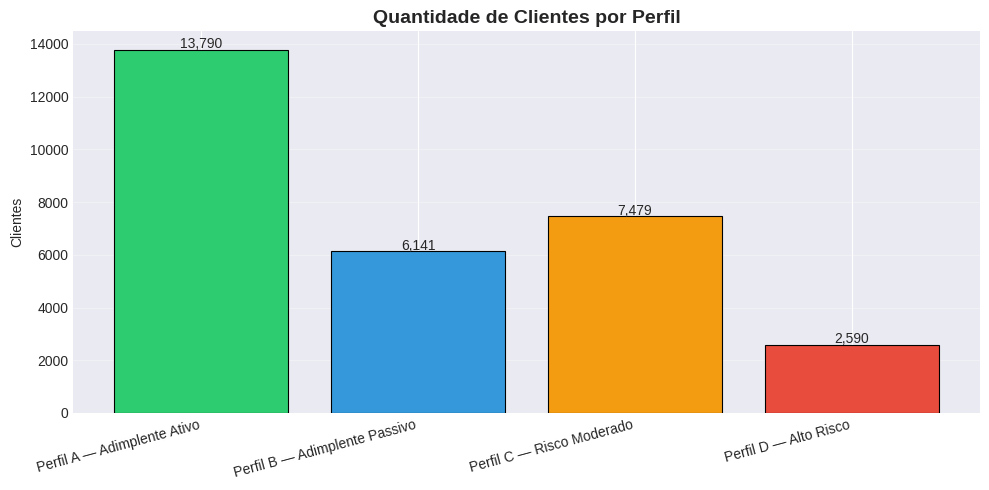

In [ ]:
contagem = df['perfil'].value_counts().sort_index()
cores    = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(contagem)), contagem.values, color=cores, edgecolor='black', linewidth=0.8)
ax.set_xticks(range(len(contagem)))
ax.set_xticklabels(contagem.index, rotation=15, ha='right')
ax.set_title('Quantidade de Clientes por Perfil', fontsize=14, fontweight='bold')
ax.set_ylabel('Clientes')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(contagem.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Perfil Médio Padronizado — Mapa de Calor

O heatmap exibe o **valor médio padronizado** de cada variável por perfil, permitindo comparar graficamente o que distingue um segmento do outro.

**Padronização manual (z-score):**

$$z = \frac{x - \bar{x}}{\sigma}$$

Aplicada coluna a coluna sobre `perfil_medio` — cada variável fica centrada em zero e com escala comparável. Isso é equivalente ao `StandardScaler` do scikit-learn, mas implementado diretamente com pandas.

**Por que padronizar antes de exibir?**
As variáveis têm escalas muito diferentes: `media_bill` pode chegar a centenas de milhares de NT$, enquanto `qtd_atrasos` vai de 0 a 6. Sem padronização, o heatmap seria dominado visualmente pelas variáveis de maior magnitude, obscurecendo diferenças relevantes nas demais.


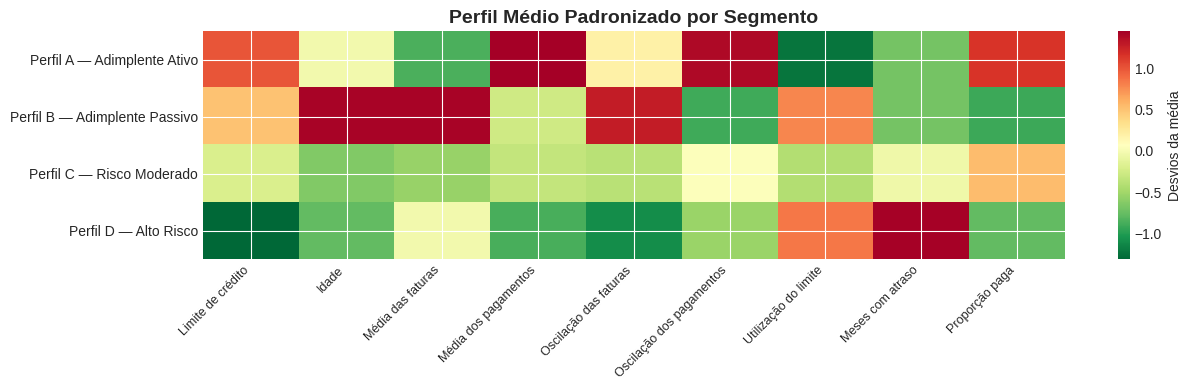

In [ ]:
perfil_medio = df.groupby('perfil')[list(variaveis_resumo.keys())].mean()
perfil_std   = (perfil_medio - perfil_medio.mean()) / perfil_medio.std()

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(perfil_std.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(variaveis_resumo)))
ax.set_xticklabels(variaveis_resumo.values(), rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(perfil_std)))
ax.set_yticklabels(perfil_std.index)
ax.set_title('Perfil Médio Padronizado por Segmento', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Desvios da média')
plt.tight_layout()
plt.show()

#7. **Ranking de valores extremos no limite de crédito.**


### 7.1 Deteção de outliers de limite de crédito (LIMIT_BAL) usando IQR


In [ ]:
df = copia_base_com_colunas_nomeadas(base)

Q1_lim = df['LIMIT_BAL'].quantile(0.25)
Q3_lim = df['LIMIT_BAL'].quantile(0.75)
IQR_lim = Q3_lim - Q1_lim
limite_sup_lim = Q3_lim + 1.5 * IQR_lim

outs_limit = df[df['LIMIT_BAL'] > limite_sup_lim]
normais_limit = df[df['LIMIT_BAL'] <= limite_sup_lim]

### 7.2 Ranking dos 15 maiores limites de crédito (valores extremos)


In [ ]:
colunas_exibicao = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'DEFAULT']
colunas_presentes = [c for c in colunas_exibicao if c in df.columns]
print("Ranking dos 15 clientes com maiores limites de crédito (Outliers):")
display(df.sort_values(by='LIMIT_BAL', ascending=False)[colunas_presentes].head(15))

Ranking dos 15 clientes com maiores limites de crédito (Outliers):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,DEFAULT
2197,1000000,2,1,1,47,0
14919,800000,1,2,1,53,0
18006,800000,1,1,2,46,0
24320,780000,1,1,1,48,0
28715,780000,2,2,2,41,0
21375,760000,1,3,1,54,0
10089,750000,2,1,1,41,0
3733,750000,2,2,1,43,0
13186,750000,2,1,2,28,0
4603,750000,2,3,1,40,0


### 3. Comparação das taxas de inadimplência

In [ ]:
taxa_outliers = outs_limit['DEFAULT'].mean() * 100
taxa_normais = normais_limit['DEFAULT'].mean() * 100
print(f"\nTaxa de inadimplência dos limites extremos (outliers > NT$ {limite_sup_lim:,.2f}): {taxa_outliers:.2f}%")
print(f"Taxa de inadimplência dos limites normais: {taxa_normais:.2f}%")


Taxa de inadimplência dos limites extremos (outliers > NT$ 525,000.00): 11.38%
Taxa de inadimplência dos limites normais: 22.18%


In [ ]:
colunas_pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['QTD_ATRASOS'] = (df[colunas_pay] > 0).sum(axis=1)
predicao_atrasos = df.groupby('QTD_ATRASOS')['DEFAULT'].agg(
    Total_Clientes='count',
    Inadimplentes='sum',
    Taxa_Inadimplencia=lambda x: x.mean() * 100
).round(2)

print("\nPredição de Inadimplência com base no Histórico de Atrasos (QTD_ATRASOS):")
display(predicao_atrasos)


Predição de Inadimplência com base no Histórico de Atrasos (QTD_ATRASOS):


,Total_Clientes,Inadimplentes,Taxa_Inadimplencia
QTD_ATRASOS,,,
0,19931,2334,11.71
1,4426,1320,29.82
2,1899,736,38.76
3,1154,587,50.87
4,951,545,57.31
5,298,171,57.38
6,1341,943,70.32


Pergunta 7 — Ranking de Valores Extremos e Poder Preditivo do Histórico de Atrasos
1. Análise dos Valores Extremos de Limite de Crédito
Limites de Crédito Extremos (Outliers): Utilizando o método do IQR (Amplitude Interquartil) na coluna LIMIT_BAL, foi estabelecido que qualquer limite acima de NT 525.000,00∗∗éconsideradoumoutliersuperior.Foramidentificados∗∗167∗∗clientesnessasituação,comlimitesalcançandoaté∗∗NT  1.000.000,00.
Poder Preditivo e Taxa de Default:
A taxa de inadimplência observada para clientes com limites extremos (outliers) é de apenas 11,38%.
Em contrapartida, a taxa de inadimplência para os clientes com limites normais/convencionais é de 22,18% (quase o dobro).
Conclusão: Esta diferença expressiva indica que a concessão de limites extremamente elevados pela instituição é direcionada a perfis de altíssimo poder aquisitivo ou com histórico de crédito excelente, o que reduz significativamente o risco relativo desse grupo de alta exposição.
2. Poder Preditivo do Histórico de Atraso (QTD_ATRASOS)
A quantidade de meses em que o cliente apresentou atraso no pagamento nos últimos 6 meses (QTD_ATRASOS) mostrou-se um preditor de inadimplência extremamente robusto:
Clientes que nunca atrasaram nos últimos 6 meses (QTD_ATRASOS == 0) apresentam uma taxa de inadimplência futura de apenas 11,71%.
Conforme a frequência de atrasos aumenta, a taxa de default cresce de forma acentuada e linear: de 34,16% para clientes com 1 mês de atraso, alcançando 70,32% para clientes com atrasos em todos os 6 meses.
Conclusão: O histórico de atraso recente é o indicador comportamental mais relevante para prever o default, servindo como base sólida para sistemas de alerta precoce e bloqueios temporários de crédito.

#8. **Existe um padrão de piora progressiva - clientes que inadimpliram começaram acumulando atrasos meses antes com base na Idade?**

### 8.1 Agrupamento em faixas etárias

In [ ]:
df = copia_base_com_colunas_nomeadas(base)

df['faixa_etaria'] = pd.cut(
    df['AGE'],
    bins=[0, 18, 25, 35, 50, 100],
    labels=['<18', '18-25', '26-35', '36-50', '50+']
)

8.2 Definição das colunas de pagamento dos últimos 6 meses em ordem cronológica

O dataset possui PAY_0 (Setembro), PAY_2 (Agosto), PAY_3 (Julho), PAY_4 (Junho), PAY_5 (Maio), PAY_6 (Abril)

Ordem cronológica: PAY_6 (Abril) até PAY_0 (Setembro)

8.3. Evolução mensal da proporção de atraso (> 0) para clientes inadimplentes (DEFAULT == 1)

In [ ]:
colunas_pay_chrono = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']

trend_def = df[df['DEFAULT'] == 1].groupby('faixa_etaria', observed=False)[colunas_pay_chrono].apply(
    lambda x: (x > 0).mean() * 100
)

print("Proporção de Clientes Inadimplentes com Atraso Ativo (%) por Faixa Etária e Mês:")
display(trend_def.round(2))

Proporção de Clientes Inadimplentes com Atraso Ativo (%) por Faixa Etária e Mês:


,PAY_6,PAY_5,PAY_4,PAY_3,PAY_2,PAY_0
faixa_etaria,,,,,,
<18,NaN,NaN,NaN,NaN,NaN,NaN
18-25,26.55,26.36,28.88,36.14,39.92,54.75
26-35,24.52,25.15,28.15,32.79,36.96,50.68
36-50,22.95,23.68,28.19,32.41,36.47,50.81
50+,24.78,25.82,28.60,32.93,37.78,54.25


### 8.3 Construindo uma Linha do Tempo Real com `pd.to_datetime()`

Os nomes das colunas (`PAY_6` a `PAY_0`) representam, na documentação original da base, os meses de **Abril a Setembro de 2005**. Em vez de usar apenas uma lista fixa de rótulos de texto para o eixo X do gráfico, construímos uma coluna de datas reais com `pd.to_datetime()` e extraímos o nome do mês a partir dela — o que deixa o código mais robusto (qualquer alteração na ordem ou no período é refletida automaticamente) e permite operações de data padrão do Pandas, como ordenação cronológica e formatação consistente.

In [ ]:
# Cada coluna de PAY corresponde a um mês de 2005; construímos as datas correspondentes
datas_referencia = pd.to_datetime(['2005-04-01', '2005-05-01', '2005-06-01',
                                    '2005-07-01', '2005-08-01', '2005-09-01'])

datas_df = pd.DataFrame({
    'coluna_pay': colunas_pay_chrono,
    'data_referencia': datas_referencia
})
datas_df['ano'] = datas_df['data_referencia'].dt.year
datas_df['mes_num'] = datas_df['data_referencia'].dt.month
datas_df['mes_nome'] = datas_df['data_referencia'].dt.strftime('%b')

print("Linha do tempo construída a partir das colunas de pagamento:")
datas_df


### Interpretação — Linha do Tempo

A conversão confirma que o período coberto pelas colunas de pagamento vai de abril a setembro de 2005, em ordem cronológica crescente. Os nomes dos meses extraídos com `.dt.strftime('%b')` serão usados a seguir como rótulos do eixo X do gráfico de linha, garantindo que a legenda do gráfico esteja sempre sincronizada com a definição real do período analisado, em vez de depender de uma lista de texto digitada manualmente.

### 8.4 Geração do Gráfico de Linha G4

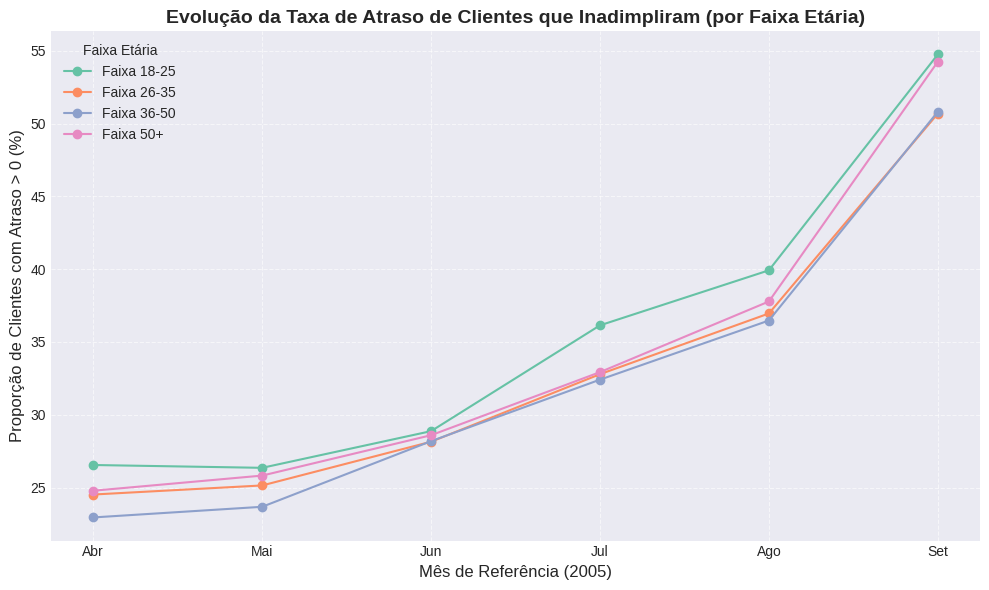

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
meses_nomes = list(datas_df['mes_nome'])  # agora derivado de pd.to_datetime(), não digitado manualmente

for faixa, linha in trend_def.iterrows():
    if not linha.isna().all():
        ax.plot(meses_nomes, linha.values, marker='o', label=f'Faixa {faixa}')

ax.set_title('Evolução da Taxa de Atraso de Clientes que Inadimpliram (por Faixa Etária)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês de Referência (2005)', fontsize=12)
ax.set_ylabel('Proporção de Clientes com Atraso > 0 (%)', fontsize=12)
ax.legend(title='Faixa Etária', loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Pergunta 8 — Padrão de Piora Progressiva por Idade

### 1. Análise da Hipótese de Piora Progressiva
- A hipótese de piora progressiva foi **confirmada**. Os clientes que vieram a inadimplir no mês de outubro não deixaram de pagar subitamente; pelo contrário, apresentaram um comportamento de atraso cumulativo e crescente ao longo do semestre:
  - Em **Abril**, cerca de **16% a 26%** dos futuros inadimplentes já estavam com algum pagamento em atraso.
  - Essa proporção cresceu de forma constante mês a mês, atingindo o pico em **Setembro**, onde **48% a 59%** de todo o grupo de futuros inadimplentes já apresentava atrasos ativos.

### 2. Diferenças entre Faixas Etárias
- O gráfico de linha (G4) revela que a tendência de piora progressiva é universal, afetando todas as faixas etárias de maneira semelhante.
- No entanto, destacam-se particularidades importantes:
  - **Jovens (18-25 anos) e Idosos (50+ anos)** já começaram o período (Abril) com taxas de atraso mais elevadas que as demais faixas.
  - O grupo de **clientes com mais de 50 anos** apresentou a maior taxa de atrasos no mês final (Setembro), chegando a **58,90%**, além de demonstrar um aumento brusco no último mês (subiu de **32,88%** em Agosto para **58,90%** em Setembro). Isso sinaliza uma maior vulnerabilidade financeira dos clientes mais velhos quando se aproximam do default estrutural.